In [ ]:
# Non Performing Loans Recovery Prediction Project

## Project Objective

The objective of this project is to analyze non-performing loan customers and rank them based on their likelihood of recovery. The dataset contains customer-level information, including gross book value, predicted probability of recovery, predicted recovery rate, predicted collections, and predicted recovery class.

The main goal is to help portfolio managers identify customers with higher recovery potential and support better collection strategies.

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
#loading datasets
df = pd.read_csv("/content/npl_sorted.csv")

df.head()

,COD_TIPO_NDG,ID_CUSTOMER,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD,PRED_RECOVERY_CLASS
0,C,27024,517.45,0.830976,0.761639,394.110118,A
1,F,17405,3032.61,0.896712,0.679352,2060.208666,A
2,G,434,283.18,0.883208,0.674150,190.905846,A
3,C,6735,467.58,0.948984,0.631884,295.456212,A
4,C,6706,500.14,0.935252,0.619070,309.621822,A


In [4]:
#Basic overview of datasets
print("Number of rows and columns:", df.shape)

Number of rows and columns: (18786, 7)


checking data types, and first few records.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18786 entries, 0 to 18785
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   COD_TIPO_NDG                  18786 non-null  object 
 1   ID_CUSTOMER                   18786 non-null  int64  
 2   IMP_GBV                       18786 non-null  float64
 3   PRED_PROB_RECOVERY_12M_AHEAD  18786 non-null  float64
 4   PRED_RECOVERY_RATE_12M_AHEAD  18786 non-null  float64
 5   PRED_INCASSI_12M_AHEAD        18786 non-null  float64
 6   PRED_RECOVERY_CLASS           18784 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 1.0+ MB


In [6]:
df.columns.tolist()

['COD_TIPO_NDG',
 'ID_CUSTOMER',
 'IMP_GBV',
 'PRED_PROB_RECOVERY_12M_AHEAD',
 'PRED_RECOVERY_RATE_12M_AHEAD',
 'PRED_INCASSI_12M_AHEAD',
 'PRED_RECOVERY_CLASS']

In [7]:
df.describe()

,ID_CUSTOMER,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD
count,18786.000000,18786.000000,18786.000000,18786.000000,18786.000000
mean,16348.353189,6061.361046,0.253307,0.059266,323.188610
std,7632.200954,4300.355655,0.239894,0.077462,504.108666
min,1.000000,0.010000,0.000000,0.000000,0.000000
25%,10317.250000,2207.740000,0.080924,0.011083,38.341898
50%,16960.500000,5598.665000,0.168598,0.032520,147.231621
75%,23046.750000,9394.207500,0.339286,0.076137,405.569226
max,28128.000000,24410.110000,0.998419,0.761639,7873.392600


##  Column Description

The dataset contains the following columns:

- `COD_TIPO_NDG`: Customer type/category code.
- `ID_CUSTOMER`: Unique customer identifier.
- `IMP_GBV`: Gross Book Value, representing the total outstanding exposure/debt amount.
- `PRED_PROB_RECOVERY_12M_AHEAD`: Predicted probability that the customer will recover within the next 12 months.
- `PRED_RECOVERY_RATE_12M_AHEAD`: Predicted recovery rate over the next 12 months.
- `PRED_INCASSI_12M_AHEAD`: Predicted cash collections over the next 12 months.
- `PRED_RECOVERY_CLASS`: Predicted recovery class/category.

The dataset is already aggregated at customer level. Each row represents one customer.

##  Missing Value Analysis

Missing values are checked to understand data quality. If missing values exist, they can be handled using median, mode, or business-based assumptions depending on the column type.

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing

,missing_count,missing_percent
PRED_RECOVERY_CLASS,2,0.010646
ID_CUSTOMER,0,0.000000
COD_TIPO_NDG,0,0.000000
IMP_GBV,0,0.000000
PRED_PROB_RECOVERY_12M_AHEAD,0,0.000000
PRED_RECOVERY_RATE_12M_AHEAD,0,0.000000
PRED_INCASSI_12M_AHEAD,0,0.000000


##  Duplicate Customer Check

Since each row should represent one customer, duplicate customer IDs are checked.

In [9]:
duplicate_customers = df["ID_CUSTOMER"].duplicated().sum()

print("Number of duplicate customer IDs:", duplicate_customers)

Number of duplicate customer IDs: 0


In [10]:
duplicate_rows = df.duplicated().sum()

print("Number of fully duplicated rows:", duplicate_rows)

Number of fully duplicated rows: 0


## Recovery Class Distribution

The recovery class is used as the target variable for classification. Checking the class distribution helps us understand whether the dataset is balanced or imbalanced.

In [11]:
df["PRED_RECOVERY_CLASS"].value_counts()

,count
PRED_RECOVERY_CLASS,
D,12153
C,3847
A,1427
B,1357


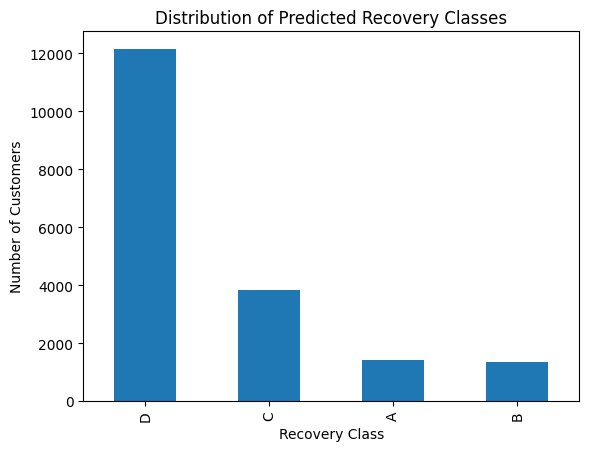

In [12]:
df["PRED_RECOVERY_CLASS"].value_counts().plot(kind="bar")

plt.title("Distribution of Predicted Recovery Classes")
plt.xlabel("Recovery Class")
plt.ylabel("Number of Customers")
plt.show()

## Gross Book Value Analysis

`IMP_GBV` represents the gross book value or outstanding debt amount. This helps us understand the exposure size of customers in the portfolio.

In [13]:
df["IMP_GBV"].describe()

,IMP_GBV
count,18786.000000
mean,6061.361046
std,4300.355655
min,0.010000
25%,2207.740000
50%,5598.665000
75%,9394.207500
max,24410.110000


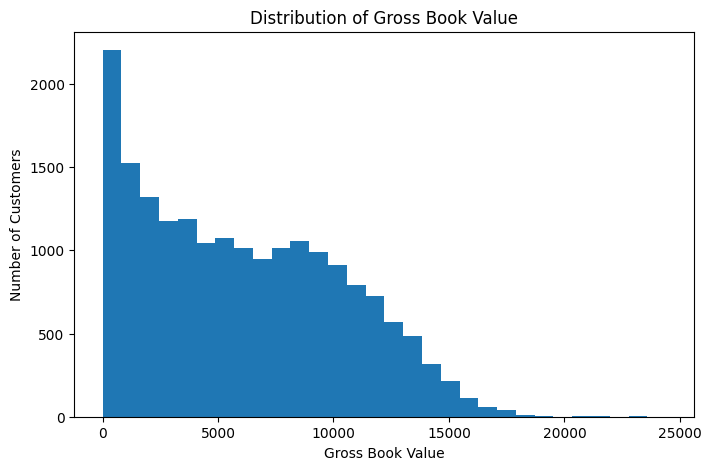

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["IMP_GBV"], bins=30)

plt.title("Distribution of Gross Book Value")
plt.xlabel("Gross Book Value")
plt.ylabel("Number of Customers")
plt.show()

## Predicted Recovery Probability Analysis

This column shows the predicted probability that a customer will recover within the next 12 months.

In [15]:
df["PRED_PROB_RECOVERY_12M_AHEAD"].describe()

,PRED_PROB_RECOVERY_12M_AHEAD
count,18786.000000
mean,0.253307
std,0.239894
min,0.000000
25%,0.080924
50%,0.168598
75%,0.339286
max,0.998419


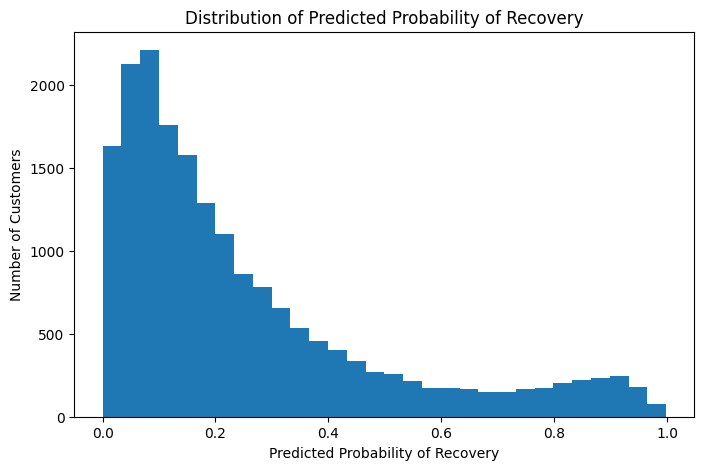

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["PRED_PROB_RECOVERY_12M_AHEAD"], bins=30)

plt.title("Distribution of Predicted Probability of Recovery")
plt.xlabel("Predicted Probability of Recovery")
plt.ylabel("Number of Customers")
plt.show()

## Correlation Analysis

Correlation analysis is used to understand relationships between numeric variables. Strong positive or negative correlations can help explain how recovery-related variables move together.

In [17]:
numeric_cols = [
    "IMP_GBV",
    "PRED_PROB_RECOVERY_12M_AHEAD",
    "PRED_RECOVERY_RATE_12M_AHEAD",
    "PRED_INCASSI_12M_AHEAD"
]

corr = df[numeric_cols].corr()
corr

,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD
IMP_GBV,1.000000,0.025987,-0.108216,0.429360
PRED_PROB_RECOVERY_12M_AHEAD,0.025987,1.000000,0.510491,0.312368
PRED_RECOVERY_RATE_12M_AHEAD,-0.108216,0.510491,1.000000,0.580217
PRED_INCASSI_12M_AHEAD,0.429360,0.312368,0.580217,1.000000


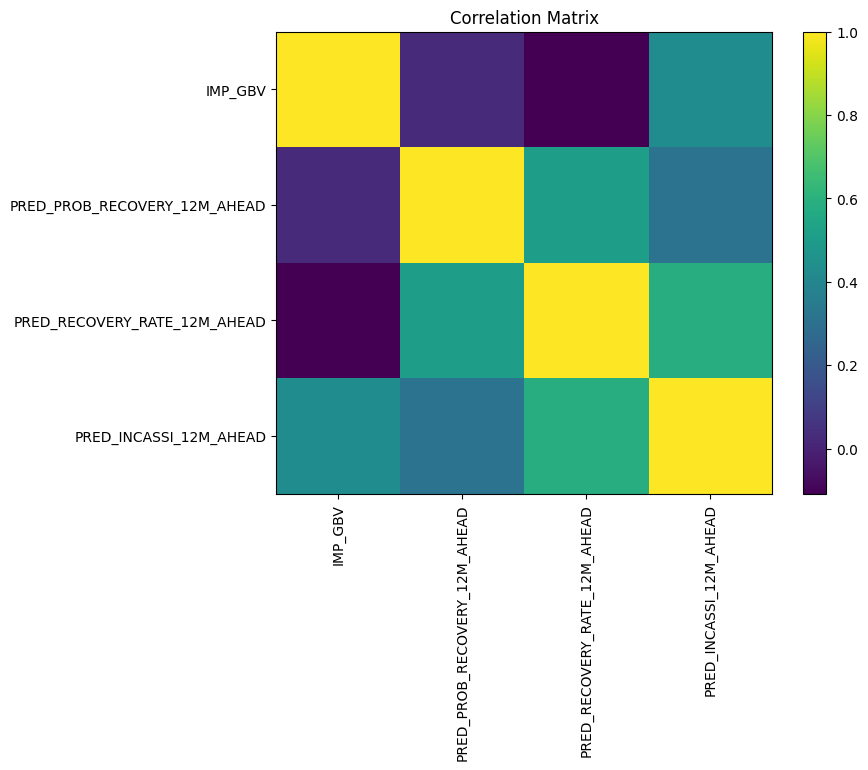

In [18]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

##  Outlier Detection

Outliers are detected using the IQR method. In financial datasets, outliers are not always wrong because some customers may naturally have very large loan exposures. Therefore, outliers should be reviewed carefully instead of automatically removed.

In [19]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    outlier_summary[col] = len(outliers)

outlier_summary_df = pd.DataFrame.from_dict(
    outlier_summary,
    orient="index",
    columns=["outlier_count"]
).sort_values("outlier_count", ascending=False)

outlier_summary_df

,outlier_count
PRED_PROB_RECOVERY_12M_AHEAD,1528
PRED_INCASSI_12M_AHEAD,1437
PRED_RECOVERY_RATE_12M_AHEAD,1347
IMP_GBV,8


##  Target Variable

In the original challenge, no target variable is directly provided. However, this available dataset already contains `PRED_RECOVERY_CLASS`, which represents the predicted recovery category of each customer.

For this project, `PRED_RECOVERY_CLASS` is selected as the target variable for classification.

The objective of the model is to classify customers into recovery classes using customer type, gross book value, predicted recovery probability, predicted recovery rate, and predicted collections.

## Feature Engineering

New features are created to improve analysis and modeling.

Three new features are created:

1. `expected_recovery_ratio`: predicted collections divided by gross book value.
2. `unrecovered_amount`: gross book value minus predicted collections.
3. `recovery_score`: predicted recovery probability multiplied by predicted recovery rate.

These features help represent recovery efficiency, remaining exposure, and overall recovery strength.

In [20]:
df["expected_recovery_ratio"] = df["PRED_INCASSI_12M_AHEAD"] / df["IMP_GBV"]

df["unrecovered_amount"] = df["IMP_GBV"] - df["PRED_INCASSI_12M_AHEAD"]

df["recovery_score"] = (
    df["PRED_PROB_RECOVERY_12M_AHEAD"] *
    df["PRED_RECOVERY_RATE_12M_AHEAD"]
)

df.head()

,COD_TIPO_NDG,ID_CUSTOMER,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD,PRED_RECOVERY_CLASS,expected_recovery_ratio,unrecovered_amount,recovery_score
0,C,27024,517.45,0.830976,0.761639,394.110118,A,0.761639,123.339882,0.632904
1,F,17405,3032.61,0.896712,0.679352,2060.208666,A,0.679352,972.401334,0.609183
2,G,434,283.18,0.883208,0.674150,190.905846,A,0.674150,92.274154,0.595415
3,C,6735,467.58,0.948984,0.631884,295.456212,A,0.631884,172.123788,0.599647
4,C,6706,500.14,0.935252,0.619070,309.621822,A,0.619070,190.518178,0.578987


In [21]:
df[[
    "ID_CUSTOMER",
    "IMP_GBV",
    "PRED_INCASSI_12M_AHEAD",
    "expected_recovery_ratio",
    "unrecovered_amount",
    "recovery_score"
]].head()

,ID_CUSTOMER,IMP_GBV,PRED_INCASSI_12M_AHEAD,expected_recovery_ratio,unrecovered_amount,recovery_score
0,27024,517.45,394.110118,0.761639,123.339882,0.632904
1,17405,3032.61,2060.208666,0.679352,972.401334,0.609183
2,434,283.18,190.905846,0.674150,92.274154,0.595415
3,6735,467.58,295.456212,0.631884,172.123788,0.599647
4,6706,500.14,309.621822,0.619070,190.518178,0.578987


## Data Preparation for Modeling

The dataset is prepared by selecting input features and the target variable. Categorical variables are converted using one-hot encoding. Missing and infinite values are handled before training the model.

In [22]:
features = [
    "COD_TIPO_NDG",
    "IMP_GBV",
    "PRED_PROB_RECOVERY_12M_AHEAD",
    "PRED_RECOVERY_RATE_12M_AHEAD",
    "PRED_INCASSI_12M_AHEAD",
    "expected_recovery_ratio",
    "unrecovered_amount",
    "recovery_score"
]

target = "PRED_RECOVERY_CLASS"

X = df[features]
y = df[target]

X.head()

,COD_TIPO_NDG,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD,expected_recovery_ratio,unrecovered_amount,recovery_score
0,C,517.45,0.830976,0.761639,394.110118,0.761639,123.339882,0.632904
1,F,3032.61,0.896712,0.679352,2060.208666,0.679352,972.401334,0.609183
2,G,283.18,0.883208,0.674150,190.905846,0.674150,92.274154,0.595415
3,C,467.58,0.948984,0.631884,295.456212,0.631884,172.123788,0.599647
4,C,500.14,0.935252,0.619070,309.621822,0.619070,190.518178,0.578987


In [23]:
X = pd.get_dummies(X, drop_first=True)

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median(numeric_only=True))

X.head()

,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD,expected_recovery_ratio,unrecovered_amount,recovery_score,COD_TIPO_NDG_F,COD_TIPO_NDG_G
0,517.45,0.830976,0.761639,394.110118,0.761639,123.339882,0.632904,False,False
1,3032.61,0.896712,0.679352,2060.208666,0.679352,972.401334,0.609183,True,False
2,283.18,0.883208,0.674150,190.905846,0.674150,92.274154,0.595415,False,True
3,467.58,0.948984,0.631884,295.456212,0.631884,172.123788,0.599647,False,False
4,500.14,0.935252,0.619070,309.621822,0.619070,190.518178,0.578987,False,False


##  Train-Test Split

The dataset is split into training and testing sets. 80% of the data is used for training and 20% is used for testing. Stratification is applied to preserve the target class distribution.

In [26]:
nan_indices = y.isnull()

X_cleaned = X[~nan_indices]
y_cleaned = y[~nan_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (15027, 9)
Testing set shape: (3757, 9)


##  Model Training

A Random Forest Classifier is used because it works well with tabular data, can capture non-linear relationships, and provides feature importance.

In [27]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

##  Model Evaluation

The model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score. These metrics help understand how well the model predicts each recovery class.

In [28]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9994676603673144


In [29]:
print(confusion_matrix(y_test, y_pred))

[[ 285    0    0    0]
 [   0  269    2    0]
 [   0    0  770    0]
 [   0    0    0 2431]]


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       285
           B       1.00      0.99      1.00       271
           C       1.00      1.00      1.00       770
           D       1.00      1.00      1.00      2431

    accuracy                           1.00      3757
   macro avg       1.00      1.00      1.00      3757
weighted avg       1.00      1.00      1.00      3757



##  Feature Importance

Feature importance shows which variables contributed the most to the model's predictions.

In [31]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
1,PRED_PROB_RECOVERY_12M_AHEAD,0.724130
6,recovery_score,0.163813
2,PRED_RECOVERY_RATE_12M_AHEAD,0.041372
4,expected_recovery_ratio,0.036554
3,PRED_INCASSI_12M_AHEAD,0.019174
0,IMP_GBV,0.006124
5,unrecovered_amount,0.005566
8,COD_TIPO_NDG_G,0.002402
7,COD_TIPO_NDG_F,0.000865


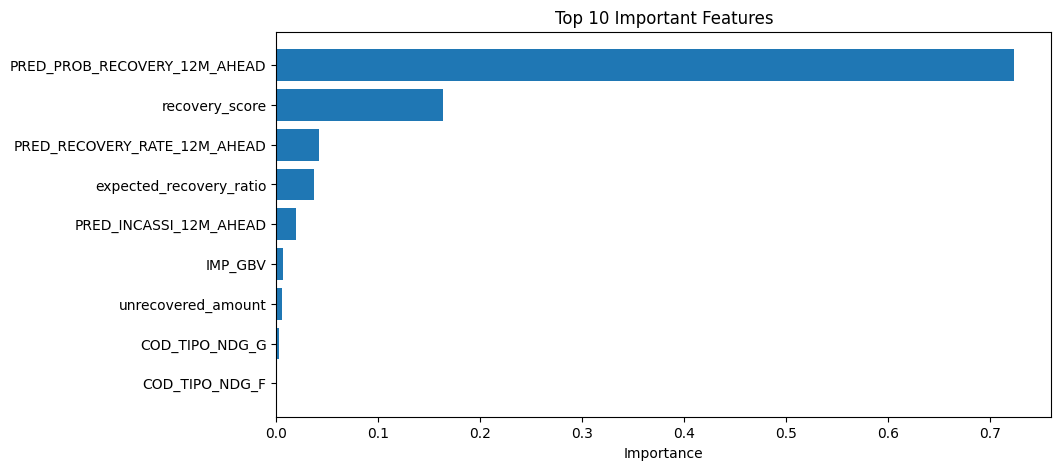

In [32]:
top_features = importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## Customer Recovery Ranking

The final business output is a ranked list of customers. Customers with higher recovery scores are expected to have stronger recovery potential.

In [33]:
ranking = df[[
    "ID_CUSTOMER",
    "COD_TIPO_NDG",
    "IMP_GBV",
    "PRED_PROB_RECOVERY_12M_AHEAD",
    "PRED_RECOVERY_RATE_12M_AHEAD",
    "PRED_INCASSI_12M_AHEAD",
    "PRED_RECOVERY_CLASS",
    "expected_recovery_ratio",
    "unrecovered_amount",
    "recovery_score"
]].sort_values("recovery_score", ascending=False)

ranking.head(20)

,ID_CUSTOMER,COD_TIPO_NDG,IMP_GBV,PRED_PROB_RECOVERY_12M_AHEAD,PRED_RECOVERY_RATE_12M_AHEAD,PRED_INCASSI_12M_AHEAD,PRED_RECOVERY_CLASS,expected_recovery_ratio,unrecovered_amount,recovery_score
0,27024,C,517.45,0.830976,0.761639,394.110118,A,0.761639,123.339882,0.632904
1,17405,F,3032.61,0.896712,0.679352,2060.208666,A,0.679352,972.401334,0.609183
3,6735,C,467.58,0.948984,0.631884,295.456212,A,0.631884,172.123788,0.599647
2,434,G,283.18,0.883208,0.674150,190.905846,A,0.674150,92.274154,0.595415
4,6706,C,500.14,0.935252,0.619070,309.621822,A,0.619070,190.518178,0.578987
5,27177,F,8210.79,0.888776,0.613533,5037.586623,A,0.613533,3173.203377,0.545293
11,15530,F,842.37,0.947028,0.571683,481.568401,A,0.571683,360.801599,0.541399
12,14608,C,1013.24,0.942002,0.568474,576.001063,A,0.568474,437.238937,0.535504
8,18357,F,771.51,0.904660,0.590411,455.507616,A,0.590411,316.002384,0.534121
10,21253,F,848.25,0.910101,0.573856,486.773088,A,0.573856,361.476912,0.522267


## Export Results

The final ranked customer list is exported as a CSV file.

In [34]:
ranking.to_csv("/content/customer_recovery_ranking.csv", index=False)

In [35]:
from google.colab import files

files.download("/content/customer_recovery_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>